<img src="assets/DemoSlidesForExport_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/DemoSlidesForExport_1.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_1.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_2.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/mCDR-2step_3.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Initialization</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star consists of python packages that are installable via <code>pip</code> — the standard Python package installer.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>

In [1]:
from datetime import datetime
import cson_forge
env = cson_forge.config.get_environment_info()
# Display env
summary = f"""
### Machine Information
- **Hostname**: `{env.hostname}`
- **System Tag**: `{env.system_tag}`
- **OS**: `{env.os_info}`

### Environment Summary
- **Python Version**: `{env.python_version}`
- **Python Executable**: `{env.python_executable}`
- **Conda/Micromamba Environment**: `{env.env_info}`
- **Kernel**: `{env.kernel_spec}`
"""
print(summary)
print("\nEnvironment check complete!\n")



### Machine Information
- **Hostname**: `hoatzin`
- **System Tag**: `MacOS`
- **OS**: `Darwin 23.6.0 (arm64)`

### Environment Summary
- **Python Version**: `3.13.13`
- **Python Executable**: `/Users/blsaenz/miniforge3/envs/cworthy-test/bin/python`
- **Conda/Micromamba Environment**: `cworthy-test (/Users/blsaenz/miniforge3/envs/cworthy-test)`
- **Kernel**: `unknown`


Environment check complete!



<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Define the dimensions that will build a ROMS model grid with plain-language names:
</p>

In [2]:
# Grid parameters ------------------------------------------------------------------
grid_name = "Gulf_of_Alaska"
grid_settings = dict[str, float](
    nx=208,              # X-direction grid cells (xi)
    ny=192,              # Y-direction grid cells (eta)
    size_x=1460,         # km (longitude direction at ~49N)
    size_y=2350,         # km (latitude direction)
    center_lon=-139.5,   
    center_lat=53,
    rot=41,              # rotation of grid (degrees)
    N=10,                # number of vertical levels
    theta_s=6.0,         # surface control parameter
    theta_b=3.0,         # bottom control parameter
    hc=250.0,            # critical depth
)
boundaries = {
        "south": True,
        "east": False,
        "north": True,
        "west": True, 
}
print("\nGrid options loaded.\n")


Grid options loaded.



<p style="font-size: large; line-height: 1.45; margin: 0;">
Next we define a test model, using a pre-defined ROMS-MARBL model specification (a <b>model-spec</b>, which contains setting to enable ROMS features and compilation to match your inputs and environment), and start and end dates.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
These changeable options are passed to the CstarSpecBuilder() object, which will find and generate the <b>forcing data</b>, and <b>C-Star blueprints</b> which will run the ROMS model and ensure <b>scientific reproducability<b>:
</p>

CstarSpecBuilder: planned NetCDF outputs
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs_grid.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs_initial_conditions.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs_surface-physics.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs_surface-bgc.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs_boundary-physics.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs/cson_roms-marbl_v0.1_Gulf_of_Alaska_16procs_boundary-bgc.nc
  - /Users/blsaenz/cson-forge-data/input-data/cson_roms

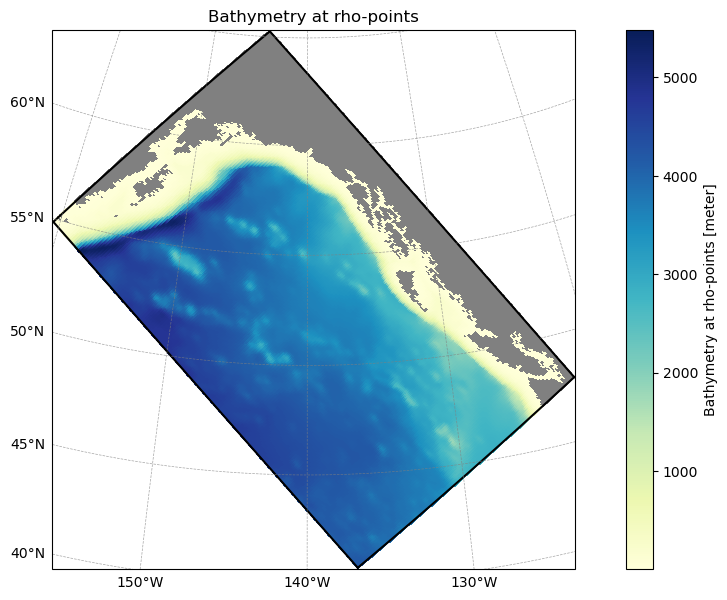

In [3]:
# Model setup ------------------------------------------------------------------
model_spec = "cson_roms-marbl_v0.1"
start_time = datetime(2010, 1, 1)
end_time = datetime(2010, 1, 10)

partitioning = {
    "n_procs_x": 4, # number of partitions in xi (x) 
    "n_procs_y": 4, # number of partitions in eta (y) 
}

# Initialize CstarSpecBuilder --------------------------------------------------
ocn = cson_forge.CstarSpecBuilder(
    description="GulfOfAlaska_test",
    model_name=model_spec,
    grid_name=grid_name,
    grid_kwargs=grid_settings,
    open_boundaries=boundaries,    
    start_time=start_time,
    end_time=end_time,
    partitioning=partitioning,
)

ocn.grid.plot()

<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Forcing Data and Blueprint Generation</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star uses online, published datasets for ocean bathymetry, atmospheric variables, and initial and boundary conditions. These datasets are either steamable directly to C-Star or are staged online by C-Worthy. Data sources are specified in the 
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>

In [ ]:
# ensure that source data is staged locally
ocn_inner.ensure_source_data()

# prepare model input
ocn_inner.generate_inputs(clobber=True) # setting clobber=True will overwrite existing files

# configure and build the model
ocn_inner.configure_build(
    compile_time_settings={}, 
    run_time_settings = {}
    #     "roms.in": {
    #         "time_stepping": {
    #             "dt": 900,
    #         }
    #     }
    # }
)